In [1]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
print(train.head())

(54808, 13)
   employee_id         department     region         education gender  \
0        65438  Sales & Marketing   region_7  Master's & above      f   
1        65141         Operations  region_22        Bachelor's      m   
2         7513  Sales & Marketing  region_19        Bachelor's      m   
3         2542  Sales & Marketing  region_23        Bachelor's      m   
4        48945         Technology  region_26        Bachelor's      m   

  recruitment_channel  no_of_trainings  age  previous_year_rating  \
0            sourcing                1   35                   5.0   
1               other                1   30                   5.0   
2            sourcing                1   34                   3.0   
3               other                2   39                   1.0   
4               other                1   45                   3.0   

   length_of_service  awards_won?  avg_training_score  is_promoted  
0                  8            0                  49            

In [2]:
print(train.isnull().sum())

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64


In [3]:
train["education"].fillna(train["education"].mode()[0], inplace=True)
test["education"].fillna(test["education"].mode()[0], inplace=True)

/tmp/ipykernel_1715/3521926144.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["education"].fillna(train["education"].mode()[0], inplace=True)
/tmp/ipykernel_1715/3521926144.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [4]:
train["previous_year_rating"].fillna(
    train["previous_year_rating"].median(),
    inplace=True
)

test["previous_year_rating"].fillna(
    test["previous_year_rating"].median(),
    inplace=True
)

/tmp/ipykernel_1715/2358344091.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["previous_year_rating"].fillna(
/tmp/ipykernel_1715/2358344091.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.m

In [5]:
print("Duplicates:", train.duplicated().sum())

train.drop_duplicates(inplace=True)

Duplicates: 0


In [6]:
X = train.drop(["employee_id", "is_promoted"], axis=1)
y = train["is_promoted"]

test_data = test.drop(["employee_id"], axis=1)

In [7]:
cat_cols = [
    "department",
    "region",
    "education",
    "gender",
    "recruitment_channel"
]

In [8]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}

for col in cat_cols:
    le = LabelEncoder()

    combined = pd.concat([X[col], test_data[col]])

    le.fit(combined)

    X[col] = le.transform(X[col])
    test_data[col] = le.transform(test_data[col])

    le_dict[col] = le

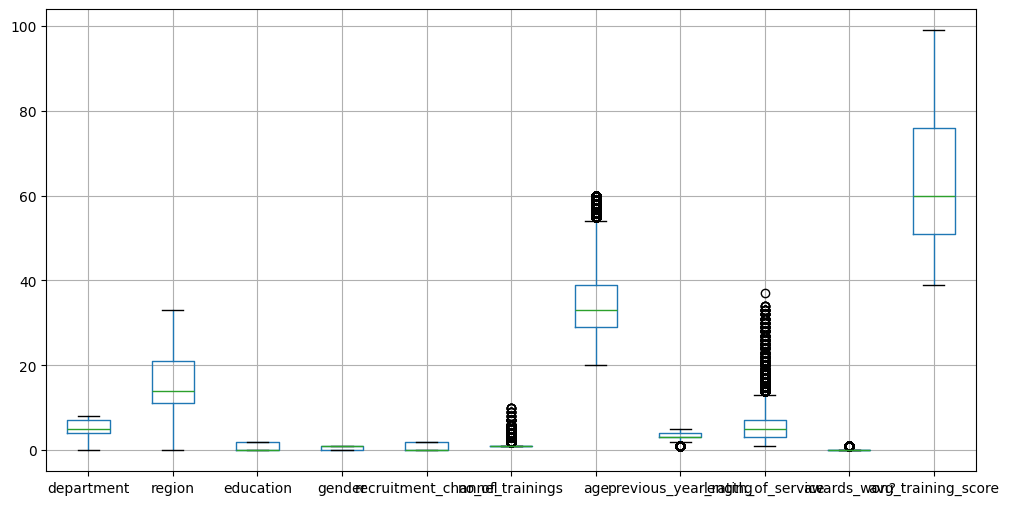

In [9]:
import matplotlib.pyplot as plt

X.boxplot(figsize=(12,6))
plt.show()

In [10]:
X["service_group"] = pd.cut(
    X["length_of_service"],
    bins=[0,5,10,20,40],
    labels=[0,1,2,3]
)

test_data["service_group"] = pd.cut(
    test_data["length_of_service"],
    bins=[0,5,10,20,40],
    labels=[0,1,2,3]
)

In [11]:
X["age_group"] = pd.cut(
    X["age"],
    bins=[20,30,40,50,60],
    labels=[0,1,2,3]
)

test_data["age_group"] = pd.cut(
    test_data["age"],
    bins=[20,30,40,50,60],
    labels=[0,1,2,3]
)

In [12]:
print(y.value_counts())

is_promoted
0    50140
1     4668
Name: count, dtype: int64


In [14]:
from imblearn.over_sampling import SMOTE

# Identify columns with NaN values in X
print("NaNs in X before SMOTE:\n", X.isnull().sum()[X.isnull().sum() > 0])

# Fill NaNs in 'service_group' and 'age_group' with their respective modes
# It's important to do this for both X and test_data
if 'service_group' in X.columns and X['service_group'].isnull().any():
    X['service_group'].fillna(X['service_group'].mode()[0], inplace=True)
if 'age_group' in X.columns and X['age_group'].isnull().any():
    X['age_group'].fillna(X['age_group'].mode()[0], inplace=True)

if 'service_group' in test_data.columns and test_data['service_group'].isnull().any():
    test_data['service_group'].fillna(test_data['service_group'].mode()[0], inplace=True)
if 'age_group' in test_data.columns and test_data['age_group'].isnull().any():
    test_data['age_group'].fillna(test_data['age_group'].mode()[0], inplace=True)

print("\nNaNs in X after imputation:\n", X.isnull().sum()[X.isnull().sum() > 0])

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

NaNs in X before SMOTE:
 age_group    113
dtype: int64

NaNs in X after imputation:
 Series([], dtype: int64)


/tmp/ipykernel_1715/1948365921.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['age_group'].fillna(X['age_group'].mode()[0], inplace=True)
/tmp/ipykernel_1715/1948365921.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_resampled = scaler.fit_transform(X_resampled)
test_scaled = scaler.transform(test_data)